In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

data = r'C:\Users\Noman khan\Downloads\archive (10)\creditcard.csv'

df = pd.read_csv(data)
print(df.head())
print(df.info())
print(df.isnull().sum())



   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [2]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


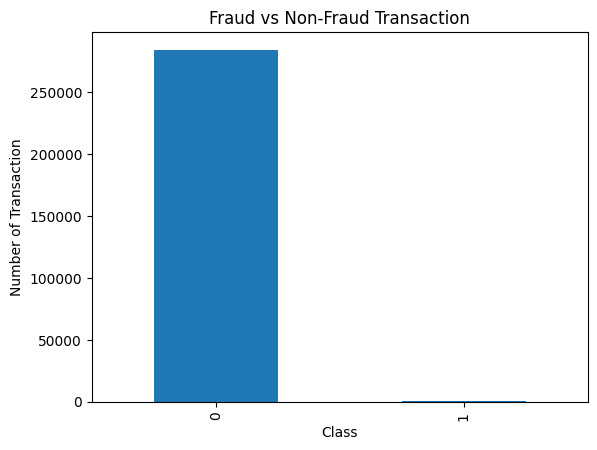

In [3]:
df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud Transaction")
plt.xlabel("Class")
plt.ylabel("Number of Transaction")
plt.show()

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train ,X_test,  y_train, y_test = train_test_split(X, y, random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


In [20]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", recall)
print("F1: ", f1)


Accuracy:  0.9992135052386169
Precision:  0.8518518518518519
Recall:  0.6106194690265486
F1:  0.711340206185567


## With Balanced target column

In [ ]:
model_bal = LogisticRegression(class_weight='balanced', max_iter=1000)
model_bal.fit(X_train_scaled, y_train)
model_bal_pred = model_bal.predict(X_test_scaled) 



In [21]:
model_bal_acc = accuracy_score(y_test, model_bal_pred)
print(model_bal_acc)
model_bal_pre = precision_score(y_test, model_bal_pred)
model_bal_rec = recall_score(y_test, model_bal_pred)
model_bal_f1 = f1_score(y_test, model_bal_pred)

0.9758152860874695


In [17]:
comparison_table = pd.DataFrame({
    "metric": ["Precision", "Recall", "F1"],
    "model(before)": [prec, recall, f1],
    "model(after balanced class)": [ model_bal_pre, model_bal_rec, model_bal_f1]
})

print(comparison_table)

      metric  model(before)  model(after balanced class)
0  Precision       0.851852                     0.057237
1     Recall       0.610619                     0.920354
2         F1       0.711340                     0.107772


## Why Accuracy is misleading here?

Because this dataset is highly imbalanced: normal transactions are far more numerous than fraudulent transactions.

If a model predicts every transaction as normal, it could still achieve very high accuracy while detecting zero fraud cases.

For example:

If 99% of transactions are normal, a model that simply predicts "normal" every time gets 99% accuracy, but it catches 0% of fraud.

Therefore, accuracy can give us a false impression that the model is performing well.

For fraud detection, Precision, Recall, and F1-score are more informative, especially Recall because we care about detecting fraudulent transactions rather than merely getting the majority class correct.